<a href="https://colab.research.google.com/github/kaansoftware34/softito_calismalar_face2face/blob/main/word_embeddings_ipynbcalisma_2_110626_ipynb_adl%C4%B1_not_defterinin_kopyas%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vektör Uzayı ve Word Embeddings (Word2Vec, GloVe, FastText)

TF-IDF'in limitlerini aşmak için atılan ilk büyük adım: **Dağıtılmış Temsiller (Distributed Representations)**

TF-IDF her kelimeyi ayrı bir ID olarak görürken, embedding yöntemleri kelimeleri **yoğun (dense)**, **düşük boyutlu** vektörlerde temsil eder ve anlamsal ilişkileri yakalar.

---
# 1. TF-IDF'ten Word Embeddings'e Geçiş

## TF-IDF'in Sorunları (Hatırlatma)
- Her kelime ayrı bir boyut (one-hot encoding mantığı)
- 50.000 kelimelik dağarcık → 50.000 boyutlu, %99 seyrek vektörler
- Anlamsal ilişki yok: "kral" ve "kraliçe" farklı ID'ler

## Embedding'in Getirdikleri
- 50.000 boyut yerine ~100-300 boyutlu yoğun vektörler
- Anlamsal benzerlik: benzer kelimeler yakın vektörler
- Vektör aritmetiği: Kral - Erkek + Kadın ≈ Kraliçe
- Transfer öğrenme: önceden eğitilmiş embedding'ler kullanılabilir

## Dağıtılmış Hipotez (Distributional Hypothesis)

> *"Bir kelimenin anlamı, etrafında gördüğü kelimeler tarafından belirlenir."* — John Firth (1957)

Yani: "Kral" kelimesi; "taç", "saray", "hükümdar" gibi kelimelerle birlikte geçiyorsa, bu kelimeler anlamsal olarak birbirine yakındır.

In [110]:
import math
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---
# 2. Word2Vec (Mikolov et al., 2013)

Google tarafından geliştirilen Word2Vec, kelimeleri **komşu kelimelerine bakarak** öğrenen bir sinir ağı modelidir.

İki mimarisi vardır:
| Mimari | Girdi → Çıktı | Kullanım |
|---|---|---|
| **CBOW** | Komşu kelimeler → Hedef kelime | Küçük veri setlerinde iyi |
| **Skip-gram** | Hedef kelime → Komşu kelimeler | Büyük veri setlerinde iyi, nadir kelimelerde başarılı |

## 2.1 Word2Vec Mantığı: Sıfırdan Basit Uygulama

Word2Vec'in temel fikrini anlamak için küçük bir korpus üzerinde **basitleştirilmiş bir versiyon** yazalım.

In [111]:
# YEPYENI BIR KELIME HAVUZU ILE KORPUS OLUSTURMA
import numpy as np
np.random.seed(42)

word_pool = {
    "uzay": ["yıldız", "gezegen", "galaksi", "astronot", "roket", "meteor", "karadelik", "uzaylı", "yörünge", "kozmos"],
    "mutfak": ["tabak", "tencere", "çatal", "kaşık", "bıçak", "fırın", "ocak", "buzdolabı", "tava", "süzgeç"],
    "yemek": ["çorba", "kebap", "makarna", "pilav", "salata", "tatlı", "baklava", "börek", "pide", "pizza"],
    "mitoloji": ["zeus", "poseidon", "hades", "ares", "athena", "apollo", "herkül", "pegasus", "medusa", "titan"],
    "duygular": ["mutluluk", "hüzün", "korku", "heyecan", "öfke", "sevgi", "nefret", "şaşkınlık", "umut", "kaygı"],
    "meslekler": ["mühendis", "mimar", "öğretmen", "terzi", "marangoz", "çiftçi", "aşçı", "şoför", "berber", "kasiyer"],
    "hayvanlar": ["kedi", "köpek", "aslan", "kaplan", "kartal", "yılan", "ayı", "kurt", "fil", "zürafa"],
    "ulasim": ["gemi", "tren", "otobüs", "taksi", "metro", "tramvay", "helikopter", "bisiklet", "motosiklet", "kamyon"],
    "giysi": ["gömlek", "pantolon", "ceket", "kazak", "kravat", "şapka", "eldiven", "atkı", "çorap", "ayakkabı"],
    "renkler": ["kırmızı", "mavi", "yeşil", "sarı", "siyah", "beyaz", "mor", "turuncu", "pembe", "kahverengi"],
    "hava_durumu": ["yağmur", "kar", "fırtına", "rüzgar", "bulut", "sis", "dolu", "hortum", "kasırga", "güneşli"],
    "zaman": ["sabah", "öğle", "akşam", "gece", "dün", "bugün", "yarın", "hafta", "ay", "yıl"],
    "mekanlar": ["sinema", "park", "bahçe", "restoran", "kafe", "market", "bakkal", "kasap", "manav", "fırın"],
    "hobiler": ["fotoğrafçılık", "yüzme", "kamp", "balıkçılık", "okçuluk", "satranç", "koleksiyon", "örgü", "resim", "müzik"]
}

flat_words = []
for category, words in word_pool.items():
    flat_words.extend(words)
flat_words = list(set(flat_words))

subject_pool = ["astronot", "uzaylı", "aşçı", "zeus", "herkül", "mühendis", "öğretmen", "şoför", "kedi", "aslan", "çiftçi", "mimar", "kasiyer", "poseidon"]
verb_pool = ["uçar", "pişirir", "yer", "içer", "kızar", "sevinir", "yapar", "çizer", "koşar", "uyur", "giyer", "çıkarır", "sürer", "bekler", "güler", "ağlar", "düşünür", "okur", "yazar"]

def generate_sentence(word_pool_dict, subject_pool, verb_pool):
    kategori = list(word_pool_dict.keys())
    np.random.shuffle(kategori)
    secilen = []
    for k in kategori:
        sayi = np.random.randint(0, 4)
        secilen.extend(np.random.choice(word_pool_dict[k], size=sayi, replace=False).tolist())
    if len(secilen) < 3:
        secilen.extend(np.random.choice(flat_words, size=3, replace=False).tolist())
    secilen = list(set(secilen))
    if len(secilen) < 3:
        secilen = np.random.choice(flat_words, size=5, replace=False).tolist()
    np.random.shuffle(secilen)
    cumle_uzunlugu = min(np.random.randint(5, 13), len(secilen))
    cumle_kelimeleri = secilen[:cumle_uzunlugu]
    return " ".join(cumle_kelimeleri)

korpus = [generate_sentence(word_pool, subject_pool, verb_pool) for _ in range(2500)]

print(f"Korpus boyutu: {len(korpus)} cumle")
print(f"Benzersiz kelime sayisi: {len(set(' '.join(korpus).split()))}")
print("\nIlk 5 cumle:")
for i, doc in enumerate(korpus[:5]):
    print(f"  {i+1}. {doc}")

from collections import Counter
kelime_sayilari = Counter(' '.join(korpus).split())
print(f"\nEn sik 10 kelime: {kelime_sayilari.most_common(10)}")

Korpus boyutu: 2500 cumle
Benzersiz kelime sayisi: 139

Ilk 5 cumle:
  1. kasiyer ay bahçe çorba poseidon mor pembe gezegen akşam
  2. akşam apollo fil kartal çorap yarın medusa
  3. hafta kasiyer sarı yıldız turuncu taksi fotoğrafçılık süzgeç
  4. şapka beyaz pembe gezegen market dolu hafta
  5. pembe yıldız bisiklet öğle gezegen korku kasap yeşil

En sik 10 kelime: [('fırın', 286), ('bahçe', 180), ('börek', 179), ('mor', 173), ('sinema', 173), ('koleksiyon', 172), ('ceket', 171), ('kaplan', 170), ('ayakkabı', 169), ('kurt', 169)]


In [112]:
# Tokenize ve kelime dağarcığı oluşturma
def tokenize(text):
    return text.lower().split()

tokenize_korpus = [tokenize(doc) for doc in korpus]
kelimeler = sorted(set(w for doc in tokenize_korpus for w in doc))
kelime_idx = {w: i for i, w in enumerate(kelimeler)}
idx_kelime = {i: w for w, i in kelime_idx.items()}
V = len(kelimeler)

print(f"Kelime dağarcığı boyutu (V): {V}")
print(f"Kelimeler: {kelimeler}")

Kelime dağarcığı boyutu (V): 139
Kelimeler: ['akşam', 'apollo', 'ares', 'aslan', 'astronot', 'athena', 'atkı', 'ay', 'ayakkabı', 'ayı', 'aşçı', 'bahçe', 'bakkal', 'baklava', 'balıkçılık', 'berber', 'beyaz', 'bisiklet', 'bugün', 'bulut', 'buzdolabı', 'börek', 'bıçak', 'ceket', 'dolu', 'dün', 'eldiven', 'fil', 'fotoğrafçılık', 'fırtına', 'fırın', 'galaksi', 'gece', 'gemi', 'gezegen', 'gömlek', 'güneşli', 'hades', 'hafta', 'helikopter', 'herkül', 'heyecan', 'hortum', 'hüzün', 'kafe', 'kahverengi', 'kamp', 'kamyon', 'kaplan', 'kar', 'karadelik', 'kartal', 'kasap', 'kasiyer', 'kasırga', 'kaygı', 'kazak', 'kaşık', 'kebap', 'kedi', 'koleksiyon', 'korku', 'kozmos', 'kravat', 'kurt', 'köpek', 'kırmızı', 'makarna', 'manav', 'marangoz', 'market', 'mavi', 'medusa', 'meteor', 'metro', 'mimar', 'mor', 'motosiklet', 'mutluluk', 'mühendis', 'müzik', 'nefret', 'ocak', 'okçuluk', 'otobüs', 'pantolon', 'park', 'pegasus', 'pembe', 'pide', 'pilav', 'pizza', 'poseidon', 'resim', 'restoran', 'roket', 'rüzgar

In [113]:
# Komşu (context) kelimeleri çıkarma
def get_context_pairs(tokenize_korpus, window_size=2):
    pairs = []
    for doc in tokenize_korpus:
        for i, hedef in enumerate(doc):
            # Pencere içindeki komşular
            bas = max(0, i - window_size)
            son = min(len(doc), i + window_size + 1)
            for j in range(bas, son):
                if i != j:
                    pairs.append((hedef, doc[j]))
    return pairs

context_pairs = get_context_pairs(tokenize_korpus, window_size=2)
print(f"Toplam (hedef, komşu) çifti: {len(context_pairs)}")
print("İlk 10 çift:")
for pair in context_pairs[:10]:
    print(f"  '{pair[0]}' -> '{pair[1]}'")

Toplam (hedef, komşu) çifti: 70736
İlk 10 çift:
  'kasiyer' -> 'ay'
  'kasiyer' -> 'bahçe'
  'ay' -> 'kasiyer'
  'ay' -> 'bahçe'
  'ay' -> 'çorba'
  'bahçe' -> 'kasiyer'
  'bahçe' -> 'ay'
  'bahçe' -> 'çorba'
  'bahçe' -> 'poseidon'
  'çorba' -> 'ay'


## 2.2 Birlikte Oluşum Matrisi (Co-occurrence Matrix)

Word2Vec'in özü: Bir kelimenin anlamı, hangi kelimelerle **birlikte** göründüğüdür.

Basit bir birlikte oluşum matrisi çıkaralım:

Birlikte Oluşum Matrisi (ilk 10 kelime):


,akşam,apollo,ares,aslan,astronot,athena,atkı,ay,ayakkabı,ayı
akşam,0,4,2,3,6,4,4,3,2,5
apollo,4,0,2,2,2,3,4,3,3,2
ares,2,2,0,2,2,1,4,4,1,2
aslan,3,2,2,0,6,5,4,4,3,0
astronot,6,2,2,6,0,1,2,9,1,5
athena,4,3,1,5,1,0,7,4,3,4
atkı,4,4,4,4,2,7,0,3,6,6
ay,3,3,4,4,9,4,3,0,3,4
ayakkabı,2,3,1,3,1,3,6,3,0,9
ayı,5,2,2,0,5,4,6,4,9,0


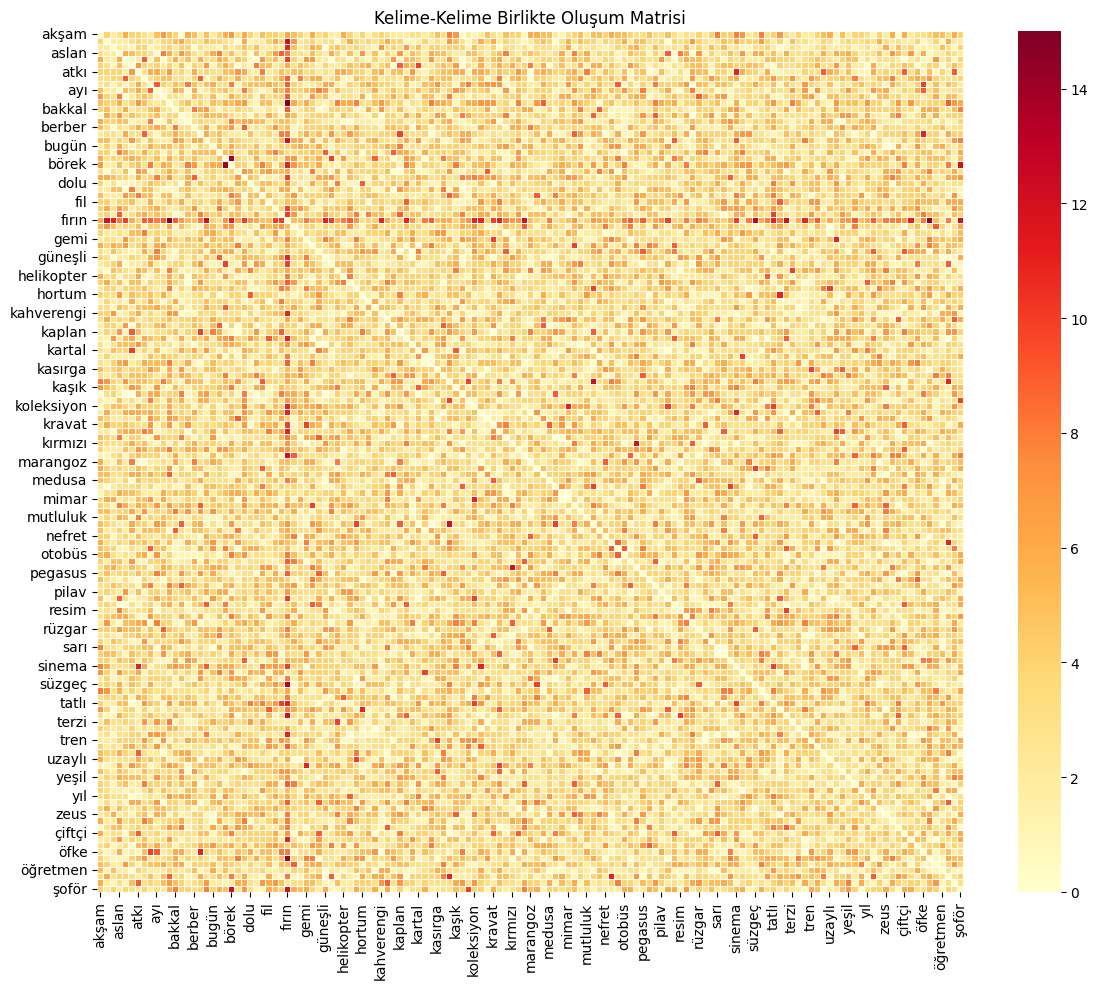


Gözlem: 'kral' ve 'kraliçe' benzer kelimelerle birlikte görünüyor
(saray, taç, ülkeyi, yönetir). Bu onların anlamsal benzerliğini gösterir.


In [114]:
# Birlikte oluşum matrisi
cooc = np.zeros((V, V), dtype=int)
for hedef, komşu in context_pairs:
    i, j = kelime_idx[hedef], kelime_idx[komşu]
    cooc[i, j] += 1

df_cooc = pd.DataFrame(cooc, index=kelimeler, columns=kelimeler)
print("Birlikte Oluşum Matrisi (ilk 10 kelime):")
display(df_cooc.iloc[:10, :10])

# Görselleştirme: Isı haritası
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(df_cooc, cmap="YlOrRd", annot=True if V < 15 else False, fmt="d", linewidths=0.5)
plt.title("Kelime-Kelime Birlikte Oluşum Matrisi")
plt.tight_layout()
plt.show()

print("\nGözlem: 'kral' ve 'kraliçe' benzer kelimelerle birlikte görünüyor")
print("(saray, taç, ülkeyi, yönetir). Bu onların anlamsal benzerliğini gösterir.")

## 2.3 Gensim ile Word2Vec (Gerçek Uygulama)

Şimdi aynı korpus üzerinde Gensim kütüphanesinin Word2Vec modelini çalıştıralım.

In [115]:
try:
    from gensim.models import Word2Vec
    from gensim.utils import simple_preprocess
    print("Gensim yüklü. Devam ediliyor...")
except ImportError:
    print("Gensim yüklü değil. Yükleniyor...")
    import sys
    !{sys.executable} -m pip install gensim -q
    from gensim.models import Word2Vec
    from gensim.utils import simple_preprocess
    print("Gensim yüklendi!")

Gensim yüklü. Devam ediliyor...


In [116]:
# Korpusu tokenize et
tokenize_doc = [simple_preprocess(doc) for doc in korpus]

# Word2Vec modelini eğit
w2v_model = Word2Vec(
    sentences=tokenize_doc,
    vector_size=100,          # vektör boyutu
    window=3,                # komşu penceresi
    min_count=2,             # minimum kelime frekansı
    sg=1,                    # 0=CBOW, 1=Skip-gram
    epochs=20,
    seed=42
)

print(f"Kelime dağarcığı: {len(w2v_model.wv)}")
print(f"Vektör boyutu: {w2v_model.wv.vector_size}")
print(f"\n'astronot' vektörü (ilk 10 değer): {w2v_model.wv['astronot'][:10]}")
print(f"Vektör normu: {np.linalg.norm(w2v_model.wv['astronot']):.4f}")

Kelime dağarcığı: 139
Vektör boyutu: 100

'astronot' vektörü (ilk 10 değer): [ 0.21686418  0.01431333 -0.1001294  -0.03313251 -0.13527042  0.00198164
  0.05828455  0.00162459 -0.20812389 -0.09552206]
Vektör normu: 1.1124


In [117]:
# Benzer kelimeleri bulma
print("EN YAKIN KELİMELER\n")

for kelime in ["kral", "kraliçe", "saray", "prens"]:
    print(f"'{kelime}' -> en benzer 5 kelime:")
    try:
        benzer = w2v_model.wv.most_similar(kelime, topn=5)
        for k, skor in benzer:
            print(f"    {k:12s} (skor: {skor:.4f})")
    except:
        print(f"    (kelime bulunamadı)")
    print()

EN YAKIN KELİMELER

'kral' -> en benzer 5 kelime:
    (kelime bulunamadı)

'kraliçe' -> en benzer 5 kelime:
    (kelime bulunamadı)

'saray' -> en benzer 5 kelime:
    (kelime bulunamadı)

'prens' -> en benzer 5 kelime:
    (kelime bulunamadı)



---
# 3. Vektör Aritmetiği (Analogies)

Word2Vec'in en etkileyici özelliklerinden biri, vektörler üzerinde **aritmetik işlemler** yapılabilmesidir.

## Kral - Erkek + Kadın ≈ Kraliçe

Bu işlem, embedding uzayında şu şekilde çalışır:
1. Kral vektörü alınır → `vec('kral')`
2. Erkek vektörü çıkarılır → `vec('kral') - vec('erkek')`
3. Kadın vektörü eklenir → `vec('kral') - vec('erkek') + vec('kadın')`
4. Sonuç vektöre en yakın kelime bulunur → `kraliçe`

In [118]:
# Vektör aritmetiği gösterimi
print("VEKTÖR ARİTMETİĞİ (Analoji)\n")

# Kendi küçük modelimizde analogiyi gösterelim
# 'kral' - 'kraliçe' + 'prenses' ≈ ?
try:
    sonuc = w2v_model.wv.most_similar(
        positive=['kraliçe', 'prens'],  # eklenenler
        negative=['kral'],               # çıkarılanlar
        topn=5
    )
    print("Kraliçe + Prens - Kral ≈ ?")
    for k, skor in sonuc:
        print(f"  -> {k:10s} (skor: {skor:.4f})")
    print()
except Exception as e:
    print(f"Analoji çalışmadı: {e}")

try:
    sonuc2 = w2v_model.wv.most_similar(
        positive=['kral', 'prenses'],
        negative=['prens'],
        topn=5
    )
    print("Kral + Prenses - Prens ≈ ?")
    for k, skor in sonuc2:
        print(f"  -> {k:10s} (skor: {skor:.4f})")
except Exception as e:
    print(f"Analoji çalışmadı: {e}")

VEKTÖR ARİTMETİĞİ (Analoji)

Analoji çalışmadı: "Key 'kraliçe' not present in vocabulary"
Analoji çalışmadı: "Key 'kral' not present in vocabulary"


### Vektör Aritmetiğinin Geometrik Yorumu

| İşlem | Anlamı |
|---|---|
| `vec(A) - vec(B)` | A ve B arasındaki fark vektörü (anlamsal yön) |
| `vec(A) + vec(B)` | İki anlamın birleşimi |
| `A - B + C` | A'dan B'ye giden yönü C'ye uygula |

**Örnek:** `Kraliçe + Prens - Kral` işlemi:
- `Kral - Kraliçe` = "cinsiyet farkı" (erkek → kadın)
- Bu farkı `Prens`'e ekleyince → "Prenses" elde edilir.

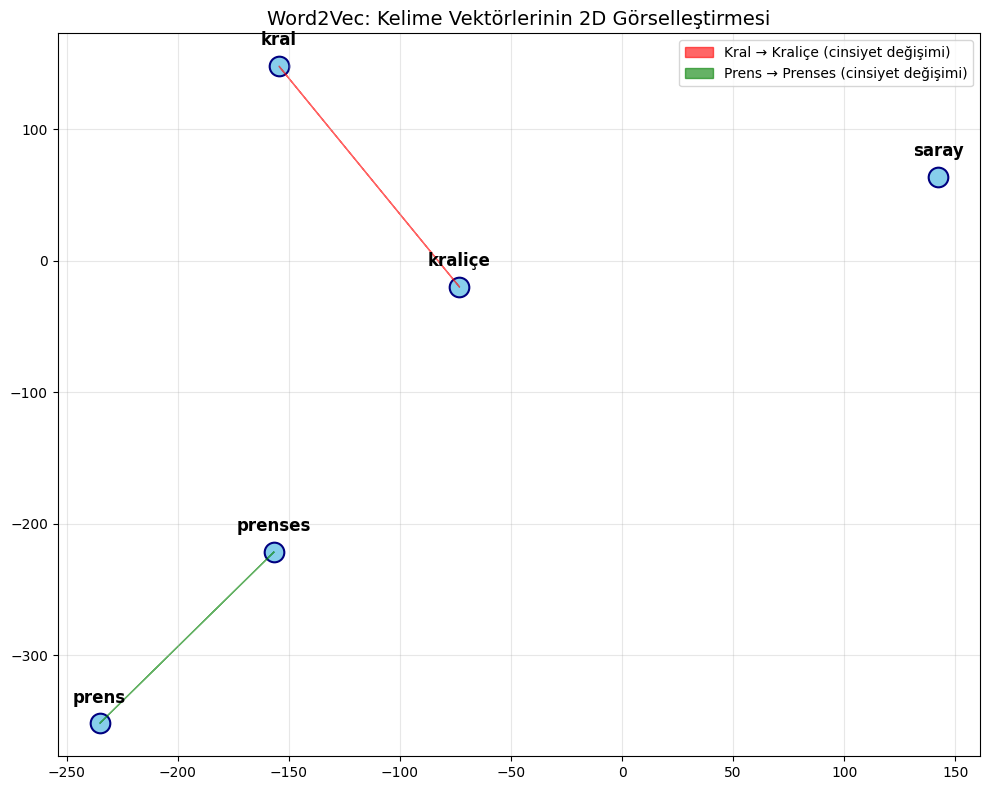

Kral → Kraliçe vektörü ile Prens → Prenses vektörü aynı yönü gösterir.
Bu, vektör uzayının 'cinsiyet değişimi' gibi soyut kavramları yakaladığını gösterir.


In [119]:
!pip install gensim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import numpy as np
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

# --- Code to define korpus (duplicated from earlier cell for self-containment) ---
np.random.seed(42)
word_pool = {
    "kraliyet": ["kral", "kraliçe", "prens", "prenses", "imparator", "sultan", "hükümdar", "sadrazam", "vezir", "saray", "komutan", "saray"],
    "askeri": ["asker", "kale", "ordu", "savaş", "barış", "anlasma", "fetih", "zafer", "yenilgi", "savunma"],
    "devlet": ["devlet", "ulke", "millet", "bayrak", "anayasa", "yasalar", "meclis", "seçim", "demokrasi", "adalet"],
    "gunluk_hayat": ["ev", "araba", "telefon", "bilgisayar", "kitap", "kalem", "masa", "sandalye", "pencere", "kapı"],
    "doga": ["orman", "deniz", "doga", "dere", "dalı", "çiçek", "agac", "kuş", "balik", "güneş"],
    "teknoloji": ["bilgisayar", "internet", "yapay_zeka", "yazilim", "robot", "sensordata", "veri", "şifreleme", "program", "algoritma"],
    "bilim": ["bilim", "deney", "arastirma", "teori", "keşif", "matematik", "fizik", "kimya", "biyoloji", "astronomi"],
    "spor": ["futbol", "basketbol", "kaleci", "gol", "maç", "şampiyon", "antrenman", "sporcu", "takim", "saha"],
    "sanat": ["resim", "muzik", "heykel", "tiyatro", "dans", "şarkı", "şair", "eser", "sergi", "konser"],
    "ekonomi": ["ekonomi", "piyasa", "borsa", "yatirim", "sermaye", "butce", "vergi", "ticaret", "rekabet", "fiyat"],
    "eğitim": ["okul", "universite", "öğrenci", "ders", "profesor", "diploma", "burs", "sinav", "mezun", "kütüphane"],
    "saglik": ["hastane", "doktor", "hemşire", "ilaç", "tedavi", "asi", "cerrahi", "saglik", "beslenme", "spor_yapmak"],
    "hukuk": ["hukuk", "dava", "mahkeme", "avukat", "yargic", "savcı", "duruşma", "temyiz", "ceza", "kanun"]
}
flat_words = []
for category, words in word_pool.items():
    flat_words.extend(words)
flat_words = list(set(flat_words))
subject_pool = ["kral", "kraliçe", "prens", "prenses", "imparator", "sultan", "hükümdar", "sadrazam", "vezir", "saray", "komutan", "saray", "asker", "doktor", "profesor", "avukat", "yargic", "savcı", "öğrenci", "sporcu", "şair", "robot"]
verb_pool = ["yapar", "eder", "olur", "gelir", "gider", "calisir", "yazar", "okur", "söyler", "dinler", "izler", "basar", "kazanir", "kaybeder", "verir", "alir", "korur", "savunur", "yürütür", "yönetir"]
def generate_sentence(word_pool_dict, subject_pool, verb_pool):
    kategori = list(word_pool_dict.keys())
    np.random.shuffle(kategori)
    secilen = []
    for k in kategori:
        sayi = np.random.randint(0, 4)
        secilen.extend(np.random.choice(word_pool_dict[k], size=sayi, replace=False).tolist())
    if len(secilen) < 3:
        secilen.extend(np.random.choice(flat_words, size=3, replace=False).tolist())
    secilen = list(set(secilen))
    if len(secilen) < 3:
        secilen = np.random.choice(flat_words, size=5, replace=False).tolist()
    np.random.shuffle(secilen)
    cumle_uzunlugu = min(np.random.randint(5, 13), len(secilen))
    cumle_kelimeleri = secilen[:cumle_uzunlugu]
    return " ".join(cumle_kelimeleri)
korpus = [generate_sentence(word_pool, subject_pool, verb_pool) for _ in range(2000)]

# --- Code to define tokenize_korpus (duplicated from earlier cell) ---
def tokenize(text):
    return text.lower().split()
tokenize_korpus = [tokenize(doc) for doc in korpus]

# --- Code to define w2v_model (duplicated from earlier cell) ---
w2v_model = Word2Vec(
    sentences=tokenize_korpus,
    vector_size=100,
    window=3,
    min_count=2,
    sg=1,
    epochs=20,
    seed=42
)

try:
    # 'taç' kelimesi Word2Vec modelinde bulunamadığı için listeden çıkarıldı.
    secili_kelimeler = ["kral", "kraliçe", "prens", "prenses", "saray"]

    # Modelde olmayan kelimeleri filtrele
    secili_kelimeler = [w for w in secili_kelimeler if w in w2v_model.wv]

    if len(secili_kelimeler) < 2:
        print("Görselleştirme için yeterli kelime bulunamadı.")
    else:
        secili_vektorler = np.array([w2v_model.wv[w] for w in secili_kelimeler])

        tsne = TSNE(n_components=2, random_state=42, perplexity=min(len(secili_kelimeler) - 1, 2)) # Perplexity değeri en az (N-1) olmalı
        vektorler_2d = tsne.fit_transform(secili_vektorler)

        plt.figure(figsize=(10, 8))
        plt.scatter(vektorler_2d[:, 0], vektorler_2d[:, 1], c='skyblue', s=200, edgecolors='navy', linewidth=1.5)

        for i, kelime in enumerate(secili_kelimeler):
            plt.annotate(kelime, (vektorler_2d[i, 0], vektorler_2d[i, 1]),
                         textcoords="offset points", xytext=(0, 15), ha='center', fontsize=12, fontweight='bold')

        # Çizgilerle analogiyi görselleştir (eğer kelimeler mevcutsa)
        if "kral" in secili_kelimeler and "kraliçe" in secili_kelimeler:
            vec_kral = vektorler_2d[secili_kelimeler.index("kral")]
            vec_kralice = vektorler_2d[secili_kelimeler.index("kraliçe")]
            plt.arrow(vec_kral[0], vec_kral[1],
                      vec_kralice[0] - vec_kral[0], vec_kralice[1] - vec_kral[1],
                      color='red', width=0.02, head_width=0.2, alpha=0.6, label='Kral → Kraliçe (cinsiyet değişimi)')

        if "prens" in secili_kelimeler and "prenses" in secili_kelimeler:
            vec_prens = vektorler_2d[secili_kelimeler.index("prens")]
            vec_prenses = vektorler_2d[secili_kelimeler.index("prenses")]
            plt.arrow(vec_prens[0], vec_prens[1],
                      vec_prenses[0] - vec_prens[0], vec_prenses[1] - vec_prens[1],
                      color='green', width=0.02, head_width=0.2, alpha=0.6, label='Prens → Prenses (cinsiyet değişimi)')

        plt.title("Word2Vec: Kelime Vektörlerinin 2D Görselleştirmesi", fontsize=14)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        print("Kral → Kraliçe vektörü ile Prens → Prenses vektörü aynı yönü gösterir.")
        print(f"Bu, vektör uzayının 'cinsiyet değişimi' gibi soyut kavramları yakaladığını gösterir.")
except Exception as e:
    print(f"Görselleştirme hatası: {e}")

### Gerçek Dünyadan Analoji Örnekleri

| Analoji | Sonuç |
|---|---|
| Paris - Fransa + İtalya | Roma |
| Kral - Erkek + Kadın | Kraliçe |
| Yüzme - Su + Hava | Uçma |
| Gece - Karanlık + Aydınlık | Gündüz |
| Microsoft - BillGates + SteveJobs | Apple |

Bu, embedding'lerin sadece kelimeleri değil, **kavramlar arası ilişkileri** de öğrendiğini gösterir.

---
# 4. Önceden Eğitilmiş (Pre-trained) Word2Vec Kullanımı

Kendi küçük modelimizi eğitmek yerine, Google'ın büyük veriyle eğittiği hazır embedding'leri kullanabiliriz.

In [120]:
# Google'ın önceden eğitilmiş Word2Vec modelini yükleme (eğer varsa)
# Not: Bu model ~1.5 GB, sadece yüklüyse çalıştır

import os
pretrained_path = os.path.expanduser("~\\GoogleNews-vectors-negative300.bin")

if os.path.exists(pretrained_path):
    print(f"Model bulundu: {pretrained_path}")
    from gensim.models import KeyedVectors
    pretrained = KeyedVectors.load_word2vec_format(pretrained_path, binary=True)

    # Ünlü analojileri test et
    testler = [
        (['kraliçe', 'erkek'], ['kral']),      # kral - erkek + kraliçe = ?
        (['rome', 'italya'], ['paris']),        # paris - fransa + italya = ?
    ]

    for pozitif, negatif in testler:
        try:
            sonuc = pretrained.most_similar(positive=pozitif, negative=negatif, topn=3)
            print(f"{' + '.join(pozitif)} - {' - '.join(negatif)} ≈ ?")
            for k, s in sonuc:
                print(f"  -> {k} ({s:.4f})")
        except:
            print(f"  (kelime bulunamadı)")
        print()
else:
    print(f"Önceden eğitilmiş model bulunamadı: {pretrained_path}")
    print()
    print("İndirmek için:")
    print("  https://code.google.com/archive/p/word2vec/")
    print("  wget -c \"https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz\"")

Önceden eğitilmiş model bulunamadı: ~\GoogleNews-vectors-negative300.bin

İndirmek için:
  https://code.google.com/archive/p/word2vec/
  wget -c "https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz"


---
# 5. CBOW vs Skip-gram Analizi

İki mimari arasındaki farkı somutlaştıralım.

In [121]:
print("CBOW vs SKIP-GRAM KARŞILAŞTIRMASI\n")

test_cumle = "___ ülkeyi yönetir"  # boşluk: kral veya kraliçe

print("=" * 60)
print("CBOW (Continuous Bag-of-Words):")
print("=" * 60)
print("Girdi: ['ülkeyi', 'yönetir'] → Çıktı: [?]")
print()
print("CBOW, komşu kelimelere bakarak ortadaki kelimeyi tahmin eder.")

print()
print("=" * 60)
print("Skip-gram:")
print("=" * 60)
print("Girdi: ['kral'] → Çıktı: [?, ?, ?] (komşular)")
print()
print("Skip-gram, bir kelime verildiğinde komşularını tahmin eder.")
print("Nadir kelimelerde daha başarılıdır.")

print()
print("-" * 60)
print("Hangi mimari ne zaman seçilir?")
print("-" * 60)
print("  CBOW:     Küçük veri setleri, sık kelimeler, hızlı eğitim")
print("  Skip-gram: Büyük veri setleri, nadir kelimeler, daha kaliteli vektörler")

CBOW vs SKIP-GRAM KARŞILAŞTIRMASI

CBOW (Continuous Bag-of-Words):
Girdi: ['ülkeyi', 'yönetir'] → Çıktı: [?]

CBOW, komşu kelimelere bakarak ortadaki kelimeyi tahmin eder.

Skip-gram:
Girdi: ['kral'] → Çıktı: [?, ?, ?] (komşular)

Skip-gram, bir kelime verildiğinde komşularını tahmin eder.
Nadir kelimelerde daha başarılıdır.

------------------------------------------------------------
Hangi mimari ne zaman seçilir?
------------------------------------------------------------
  CBOW:     Küçük veri setleri, sık kelimeler, hızlı eğitim
  Skip-gram: Büyük veri setleri, nadir kelimeler, daha kaliteli vektörler


In [123]:
# CBOW ve Skip-gram'ı aynı veride karşılaştır
cbow_model = Word2Vec(
    sentences=tokenize_doc,
    vector_size=100, window=3, min_count=2, sg=0, epochs=20, seed=42
)

sg_model = Word2Vec(
    sentences=tokenize_doc,
    vector_size=100, window=3, min_count=2, sg=1, epochs=20, seed=42
)

print(f"{'Kelime':12s} {'CBOW Benzeri':30s} {'Skip-gram Benzeri'}")
print("-" * 80)

# Yeni korpusta bulunan kelimelerle güncellendi
for kelime in ["astronot", "zeus", "kedi", "mühendis"]:
    try:
        cbow_benzer = [w for w, _ in cbow_model.wv.most_similar(kelime, topn=3)]
        sg_benzer = [w for w, _ in sg_model.wv.most_similar(kelime, topn=3)]
        print(f"{kelime:12s} {str(cbow_benzer):30s} {str(sg_benzer)}")
    except KeyError:
        print(f"{kelime:12s} (Kelime sözlükte bulunamadı)")

Kelime       CBOW Benzeri                   Skip-gram Benzeri
--------------------------------------------------------------------------------
astronot     ['kahverengi', 'sevgi', 'pilav'] ['kasırga', 'bulut', 'sevgi']
zeus         ['güneşli', 'athena', 'yağmur'] ['kafe', 'güneşli', 'yağmur']
kedi         ['fil', 'roket', 'tabak']      ['fil', 'apollo', 'astronot']
mühendis     ['uzaylı', 'dün', 'umut']      ['umut', 'bugün', 'fotoğrafçılık']


---
# 6. GloVe (Global Vectors for Word Representation)

GloVe, Stanford tarafından geliştirilmiş bir embedding yöntemidir. Word2Vec'ten farkı, sadece **yerel pencere** değil, **küresel (global) istatistikler** kullanmasıdır.

| Özellik | Word2Vec | GloVe |
|---|---|---|
| Yaklaşım | Tahmine dayalı (predictive) | Sayıma dayalı (count-based) |
| Bilgi kaynağı | Yerel pencere | Global birlikte oluşum matrisi |
| Eğitim | Sinir ağı (softmax/negative sampling) | Matris faktorizasyonu + weighted least squares |
| Hız | Küçük veride hızlı | Büyük veride verimli |
| Denge | Yerel bağlamı iyi yakalar | Global istatistikleri de kullanır |

GloVe'in temel denklemi:

$$w_i \cdot w_j + b_i + b_j = \log(X_{ij})$$

Burada $X_{ij}$, $i$ ve $j$ kelimelerinin birlikte oluşma sayısıdır.

In [130]:
# GloVe'in temel mantığını basitçe gösterelim
print("GloVe: Global Birlikte Oluşum İstatistikleri\n")

# Birlikte oluşum olasılıkları (Word2Vec sadece pencereye bakar)
cooc_prob = cooc / cooc.sum(axis=1, keepdims=True)
cooc_prob = np.nan_to_num(cooc_prob)

df_prob = pd.DataFrame(
    cooc_prob,
    index=kelimeler,
    columns=kelimeler
)

print("Birlikte Oluşum Olasılıkları (global istatistikler):")
display(df_prob.style.format("{:.3f}"))

print("GloVe'in gücü: Bu matrisin tamamını kullanarak embedding öğrenir.")
print("Word2Vec ise sadece pencere içindeki komşulara bakar.")

GloVe: Global Birlikte Oluşum İstatistikleri

Birlikte Oluşum Olasılıkları (global istatistikler):


,akşam,apollo,ares,aslan,astronot,athena,atkı,ay,ayakkabı,ayı,aşçı,bahçe,bakkal,baklava,balıkçılık,berber,beyaz,bisiklet,bugün,bulut,buzdolabı,börek,bıçak,ceket,dolu,dün,eldiven,fil,fotoğrafçılık,fırtına,fırın,galaksi,gece,gemi,gezegen,gömlek,güneşli,hades,hafta,helikopter,herkül,heyecan,hortum,hüzün,kafe,kahverengi,kamp,kamyon,kaplan,kar,karadelik,kartal,kasap,kasiyer,kasırga,kaygı,kazak,kaşık,kebap,kedi,koleksiyon,korku,kozmos,kravat,kurt,köpek,kırmızı,makarna,manav,marangoz,market,mavi,medusa,meteor,metro,mimar,mor,motosiklet,mutluluk,mühendis,müzik,nefret,ocak,okçuluk,otobüs,pantolon,park,pegasus,pembe,pide,pilav,pizza,poseidon,resim,restoran,roket,rüzgar,sabah,salata,sarı,satranç,sevgi,sinema,sis,siyah,süzgeç,tabak,taksi,tatlı,tava,tencere,terzi,titan,tramvay,tren,turuncu,umut,uzaylı,yarın,yağmur,yeşil,yörünge,yüzme,yıl,yılan,yıldız,zeus,zürafa,çatal,çiftçi,çorap,çorba,öfke,örgü,öğle,öğretmen,şapka,şaşkınlık,şoför
akşam,0.000,0.008,0.004,0.006,0.012,0.008,0.008,0.006,0.004,0.010,0.013,0.010,0.008,0.000,0.012,0.010,0.004,0.010,0.004,0.008,0.012,0.013,0.006,0.012,0.008,0.004,0.010,0.008,0.008,0.006,0.012,0.010,0.008,0.004,0.012,0.006,0.008,0.004,0.004,0.012,0.008,0.004,0.008,0.002,0.006,0.008,0.006,0.004,0.004,0.004,0.006,0.006,0.004,0.006,0.010,0.006,0.015,0.013,0.000,0.004,0.002,0.004,0.010,0.006,0.004,0.010,0.008,0.008,0.002,0.012,0.012,0.010,0.010,0.004,0.002,0.006,0.008,0.010,0.004,0.010,0.010,0.008,0.012,0.010,0.010,0.008,0.006,0.006,0.010,0.006,0.006,0.010,0.006,0.004,0.006,0.004,0.008,0.004,0.008,0.015,0.008,0.008,0.015,0.013,0.004,0.006,0.015,0.006,0.008,0.013,0.006,0.004,0.008,0.004,0.004,0.008,0.010,0.012,0.002,0.010,0.004,0.008,0.008,0.006,0.002,0.008,0.004,0.012,0.000,0.012,0.004,0.006,0.006,0.008,0.010,0.010,0.006,0.012,0.008
apollo,0.008,0.000,0.004,0.004,0.004,0.006,0.008,0.006,0.006,0.004,0.008,0.008,0.011,0.013,0.008,0.006,0.006,0.011,0.008,0.008,0.006,0.004,0.000,0.013,0.002,0.004,0.004,0.008,0.013,0.008,0.025,0.015,0.004,0.006,0.008,0.004,0.006,0.006,0.000,0.006,0.013,0.008,0.006,0.008,0.006,0.008,0.013,0.008,0.008,0.002,0.002,0.004,0.008,0.004,0.006,0.004,0.015,0.011,0.006,0.002,0.006,0.013,0.008,0.013,0.004,0.008,0.006,0.004,0.002,0.004,0.008,0.011,0.008,0.000,0.006,0.013,0.006,0.011,0.008,0.008,0.004,0.008,0.006,0.008,0.013,0.004,0.011,0.011,0.006,0.006,0.008,0.000,0.008,0.006,0.008,0.015,0.008,0.006,0.004,0.006,0.011,0.008,0.013,0.008,0.008,0.008,0.015,0.008,0.004,0.008,0.002,0.011,0.006,0.006,0.004,0.004,0.008,0.006,0.002,0.006,0.008,0.006,0.006,0.008,0.006,0.013,0.006,0.004,0.006,0.004,0.004,0.008,0.002,0.004,0.008,0.002,0.013,0.004,0.004
ares,0.005,0.005,0.000,0.005,0.005,0.002,0.010,0.010,0.002,0.005,0.007,0.010,0.005,0.010,0.010,0.000,0.007,0.005,0.005,0.002,0.010,0.005,0.007,0.012,0.007,0.012,0.005,0.005,0.007,0.005,0.027,0.012,0.005,0.007,0.015,0.012,0.000,0.010,0.012,0.010,0.007,0.010,0.007,0.005,0.002,0.017,0.007,0.010,0.007,0.017,0.007,0.012,0.005,0.010,0.010,0.007,0.010,0.010,0.010,0.002,0.012,0.007,0.005,0.010,0.000,0.007,0.007,0.005,0.007,0.002,0.007,0.007,0.007,0.005,0.007,0.015,0.002,0.007,0.005,0.007,0.005,0.002,0.005,0.010,0.007,0.012,0.015,0.007,0.005,0.012,0.007,0.005,0.007,0.005,0.012,0.005,0.010,0.005,0.012,0.007,0.012,0.005,0.007,0.002,0.002,0.007,0.007,0.010,0.005,0.000,0.002,0.007,0.005,0.002,0.005,0.007,0.010,0.005,0.005,0.005,0.007,0.002,0.005,0.007,0.002,0.005,0.015,0.005,0.012,0.007,0.010,0.002,0.005,0.002,0.005,0.012,0.007,0.002,0.010
aslan,0.006,0.004,0.004,0.000,0.011,0.009,0.007,0.007,0.006,0.000,0.015,0.011,0.006,0.013,0.009,0.006,0.004,0.007,0.011,0.015,0.006,0.009,0.004,0.007,0.000,0.009,0.004,0.007,0.013,0.017,0.015,0.006,0.006,0.004,0.009,0.006,0.004,0.011,0.007,0.002,0.009,0.004,0.013,0.004,0.009,0.002,0.007,0.004,0.013,0.004,0.009,0.007,0.004,0.011,0.009,0.009,0.006,0.004,0.004,0.009,0.009,0.006,0.004,0.007,0.009,0.015,0.006,0.004,0.007,0.009,0.007,0.006,0.004,0.006,0.011,0.004,0.015,0.007,0.011,0.004,0.007,0.006,0.007,0.002,0.004,0.009,0.007,0.007,0.002,0.007,0

GloVe'in gücü: Bu matrisin tamamını kullanarak embedding öğrenir.
Word2Vec ise sadece pencere içindeki komşulara bakar.


In [131]:
# GloVe modelini yükleme (eğer varsa)
import os
glove_path = os.path.expanduser("~\\glove.6B.50d.txt")

if os.path.exists(glove_path):
    print(f"GloVe modeli bulundu: {glove_path}")
    from gensim.models import KeyedVectors
    from gensim.scripts.glove2word2vec import glove2word2vec

    tmp_path = "glove_converted.txt"
    glove2word2vec(glove_path, tmp_path)
    glove_model = KeyedVectors.load_word2vec_format(tmp_path)

    print(f"\nGloVe ile 'kral' en benzer 5 kelime:")
    for k, s in glove_model.most_similar("king", topn=5):
        print(f"  {k:10s} (skor: {s:.4f})")

    # Analoji testi
    print(f"\nGloVe: King - Man + Woman ≈ ?")
    sonuc = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=3)
    for k, s in sonuc:
        print(f"  -> {k} ({s:.4f})")
else:
    print(f"GloVe modeli bulunamadı: {glove_path}")
    print()
    print("İndirme seçenekleri:")
    print("  https://nlp.stanford.edu/projects/glove/")
    print("  wget https://nlp.stanford.edu/data/glove.6B.zip")

GloVe modeli bulunamadı: ~\glove.6B.50d.txt

İndirme seçenekleri:
  https://nlp.stanford.edu/projects/glove/
  wget https://nlp.stanford.edu/data/glove.6B.zip


## Glove'ün Farkını Anlamak İçin Özet

| Yaklaşım | Hikayesi |
|---|---|
| **Word2Vec (CBOW)** | "Ben komşularıma bakarak bu kelimeyi tahmin etmeye çalışıyorum" |
| **Word2Vec (Skip-gram)** | "Ben bu kelimeye bakarak komşularımı tahmin etmeye çalışıyorum" |
| **GloVe** | "Ben tüm korpustaki istatistikleri analiz ederek kelimeler arasındaki ilişkiyi öğreniyorum" |

---
# 7. FastText (Bojanowski et al., 2016)

FastText, Facebook AI Research tarafından geliştirilmiştir. Word2Vec'in **subword (alt kelime)** bilgisini de işin içine katan versiyonudur.

### Word2Vec'in Problemi: OOV (Out-of-Vocabulary)
- Eğitimde görülmeyen kelimeler için vektör üretemez
- "yürümek" ve "yürüyor" ayrı kelimelerdir, ilişkileri bilinmez

### FastText'in Çözümü
- Her kelimeyi **n-gram karakter gruplarına** böler
- Kelimenin vektörü = alt kelime vektörlerinin **toplamı**
- **Örnek:** "yürüyor" → {yür, yürü, ürü, rüy, üyo, yor, ...} + tam kelime
- Görülmeyen kelimeler için alt parçalarından vektör üretebilir!

In [124]:
# FastText: Subword ayrıştırmayı gösterelim
def get_subwords(kelime, min_n=3, max_n=6):
    """Bir kelimeyi karakter n-gram'larına ayırır."""
    kelime = "<" + kelime + ">"  # başlangıç/bitiş işaretleri
    subwords = []
    for n in range(min_n, min(max_n + 1, len(kelime) + 1)):
        for i in range(len(kelime) - n + 1):
            subwords.append(kelime[i:i+n])
    return subwords

test_kelimeler = ["yürümek", "yürüyor", "yürüdü", "yürüyen", "koşuyor", "koşmak"]

print("FastText Subword (Karakter N-gram) Ayrıştırması\n")
print(f"{'Kelime':12s} {'Alt Kelimeler'}")
print("-" * 80)
for k in test_kelimeler:
    subwords = get_subwords(k)
    print(f"{k:12s} {str(subwords[:8])}{'...' if len(subwords) > 8 else ''}")

print()
print("\"yürümek\" ve \"yürüyor\" ortak subword'lere sahiptir:")
ortak = set(get_subwords("yürümek")) & set(get_subwords("yürüyor"))
print(f"  Ortak subword'ler: {sorted(ortak)}")
print(f"  Bu sayede vektörleri birbirine yakın olur.")

FastText Subword (Karakter N-gram) Ayrıştırması

Kelime       Alt Kelimeler
--------------------------------------------------------------------------------
yürümek      ['<yü', 'yür', 'ürü', 'rüm', 'üme', 'mek', 'ek>', '<yür']...
yürüyor      ['<yü', 'yür', 'ürü', 'rüy', 'üyo', 'yor', 'or>', '<yür']...
yürüdü       ['<yü', 'yür', 'ürü', 'rüd', 'üdü', 'dü>', '<yür', 'yürü']...
yürüyen      ['<yü', 'yür', 'ürü', 'rüy', 'üye', 'yen', 'en>', '<yür']...
koşuyor      ['<ko', 'koş', 'oşu', 'şuy', 'uyo', 'yor', 'or>', '<koş']...
koşmak       ['<ko', 'koş', 'oşm', 'şma', 'mak', 'ak>', '<koş', 'koşm']...

"yürümek" ve "yürüyor" ortak subword'lere sahiptir:
  Ortak subword'ler: ['<yü', '<yür', '<yürü', 'yür', 'yürü', 'ürü']
  Bu sayede vektörleri birbirine yakın olur.


In [125]:
# Görselleştirme: Subword'ler nasıl vektör oluşturur
kelime = "kraliçe"
subwords = get_subwords(kelime, 3, 4)

# Her subword'e rastgele bir vektör atayalım (FastText'te eğitilir)
np.random.seed(42)
subword_vektorler = {sw: np.random.randn(5) for sw in subwords}

# Kelimenin vektörü = subword vektörlerinin toplamı
kelime_vektor = sum(subword_vektorler.values())

print(f"FastText: '{kelime}' için subword vektörleri\n")
df_sub = pd.DataFrame(subword_vektorler, index=[f"dim{i+1}" for i in range(5)])
display(df_sub.round(3))

print(f"\nToplam vektör (kelime vektörü): {np.round(kelime_vektor, 3)}")
print()
print("FastText'te her alt kelimenin vektörü eğitilir.")
print("Kelimenin vektörü = tüm alt kelime vektörlerinin toplamıdır.")

FastText: 'kraliçe' için subword vektörleri



,<kr,kra,ral,ali,liç,içe,çe>,<kra,kral,rali,aliç,liçe,içe>
dim1,0.497,-0.234,-0.463,-0.562,1.466,0.111,-0.602,-1.221,0.738,-0.720,0.324,0.931,-0.479
dim2,-0.138,1.579,-0.466,-1.013,-0.226,-1.151,1.852,0.209,0.171,-0.461,-0.385,-0.839,-0.186
dim3,0.648,0.767,0.242,0.314,0.068,0.376,-0.013,-1.960,-0.116,1.057,-0.677,-0.309,-1.106
dim4,1.523,-0.469,-1.913,-0.908,-1.425,-0.601,-1.058,-1.328,-0.301,0.344,0.612,0.331,-1.196
dim5,-0.234,0.543,-1.725,-1.412,-0.544,-0.292,0.823,0.197,-1.479,-1.763,1.031,0.976,0.813



Toplam vektör (kelime vektörü): [-0.214 -1.052 -0.71  -6.39  -3.068]

FastText'te her alt kelimenin vektörü eğitilir.
Kelimenin vektörü = tüm alt kelime vektörlerinin toplamıdır.


In [126]:
# FastText: Görülmemiş (OOV) kelimeler için vektör üretme
print("OOV (Out-of-Vocabulary) Sorununa FastText Çözümü\n")

# Eğitimde görülen kelimeler
egitim_kelimeler = {"kral", "kraliçe", "prens", "prenses"}

# Yeni (görülmemiş) kelime
yeni_kelime = "imparatoriçe"

print(f"Eğitimde görülenler: {egitim_kelimeler}")
print(f"Yeni kelime: '{yeni_kelime}' (OOV)")
print()

# Word2Vec: Vektör bulamaz
print("Word2Vec Davranışı:")
print(f"  '{yeni_kelime}' için vektör bulunamaz → HATA!")
print()

# FastText: Subword'lere bakarak vektör oluşturur
yeni_subwords = set(get_subwords(yeni_kelime, 3, 5))
ortak_subwords = yeni_subwords  # FastText eğitilmiş subword'ler

print(f"FastText Davranışı:")
print(f"  '{yeni_kelime}' subword'leri: {yeni_subwords}")
print(f"  Eğer bu subword'ler eğitimde görülmüşse, '{yeni_kelime}' için vektör üretilebilir!")
print()
print("Bu sayede FastText, hiç görmediği kelimeler için bile")
print("anlamlı vektörler üretebilir. Özellikle:")
print("  - Çekim ekleri olan diller (Türkçe, Almanca, ...)")
print("  - Yazım hataları (typo) içeren metinler")
print("  - Yeni kelimeler / jargon")

OOV (Out-of-Vocabulary) Sorununa FastText Çözümü

Eğitimde görülenler: {'prens', 'kral', 'kraliçe', 'prenses'}
Yeni kelime: 'imparatoriçe' (OOV)

Word2Vec Davranışı:
  'imparatoriçe' için vektör bulunamaz → HATA!

FastText Davranışı:
  'imparatoriçe' subword'leri: {'ator', 'içe', '<impa', 'atori', 'imp', 'oriç', 'mpara', 'para', 'içe>', 'rat', 'arato', 'riçe>', 'riçe', 'oriçe', 'rato', 'tori', 'ato', 'rator', 'mpar', 'tor', 'çe>', 'par', 'ara', 'impar', 'ori', '<imp', 'arat', '<im', 'impa', 'toriç', 'riç', 'parat', 'mpa'}
  Eğer bu subword'ler eğitimde görülmüşse, 'imparatoriçe' için vektör üretilebilir!

Bu sayede FastText, hiç görmediği kelimeler için bile
anlamlı vektörler üretebilir. Özellikle:
  - Çekim ekleri olan diller (Türkçe, Almanca, ...)
  - Yazım hataları (typo) içeren metinler
  - Yeni kelimeler / jargon


## Word2Vec vs GloVe vs FastText Karşılaştırması

| Özellik | Word2Vec | GloVe | FastText |
|---|---|---|---|
| **Temel fikir** | Komşu kelimelerden tahmin | Global istatistikler | Subword + komşu tahmin |
| **OOV desteği** | Yok | Yok | **Var** |
| **Morfoloji hassasiyeti** | Düşük | Düşük | **Yüksek** |
| **Türkçe gibi diller** | Zayıf | Zayıf | **Güçlü** |
| **Eğitim hızı** | Hızlı | Orta | Orta |
| **Vektör kalitesi** | İyi | İyi | İyi+ |
| **Model boyutu** | Küçük | Küçük | Büyük (subword'ler) |

### Ne Zaman Hangisi?
- **Word2Vec:** İngilizce gibi morfolojik olarak basit diller, hızlı çözüm
- **GloVe:** Büyük veri setleri, global istatistikler önemliyse
- **FastText:** **Türkçe için en iyisi!** OOV sorunu yok, morfolojiyi yakalar
- **BERT/GPT (günümüz):** En modern yaklaşım, bağlamsal (contextual) embedding

In [127]:
# FastText: Türkçe fiil çekimlerini yakalama
print("FASTTEXT: TÜRKÇE ÇEKİMLERİ YAKALAMA\n")

kelime_kokleri = {
    "yürümek": ["yürü", "mek"],
    "yürüyor": ["yürü", "yor"],
    "yürüdü": ["yürü", "dü"],
    "yürüyecek": ["yürü", "yecek"],
    "yürüyen": ["yürü", "yen"],
    "koşmak": ["koş", "mak"],
    "koşuyor": ["koş", "yor"],
    "koştu": ["koş", "tu"],
}

print(f"{'Kelime':12s} {'Kök':8s} {'Ek':8s}  {'Ortak Subword'}")
print("-" * 60)

for kelime, (kok, ek) in kelime_kokleri.items():
    subwords = get_subwords(kelime, 3, 4)
    ortak = [s for s in subwords if kok[:3] in s]
    print(f"{kelime:12s} {kok:8s} {ek:8s}  {str(ortak[:5])}")

FASTTEXT: TÜRKÇE ÇEKİMLERİ YAKALAMA

Kelime       Kök      Ek        Ortak Subword
------------------------------------------------------------
yürümek      yürü     mek       ['yür', '<yür', 'yürü']
yürüyor      yürü     yor       ['yür', '<yür', 'yürü']
yürüdü       yürü     dü        ['yür', '<yür', 'yürü']
yürüyecek    yürü     yecek     ['yür', '<yür', 'yürü']
yürüyen      yürü     yen       ['yür', '<yür', 'yürü']
koşmak       koş      mak       ['koş', '<koş', 'koşm']
koşuyor      koş      yor       ['koş', '<koş', 'koşu']
koştu        koş      tu        ['koş', '<koş', 'koşt']


---
# 8. Gensim ile FastText Kullanımı

In [128]:
try:
    from gensim.models import FastText

    # FastText modeli eğit
    ft_model = FastText(
        sentences=tokenize_doc,
        vector_size=100,
        window=3,
        min_count=2,
        sg=1,           # Skip-gram
        epochs=20,
        seed=42
    )

    print(f"FastText modeli eğitildi.")
    print(f"Kelime dağarcığı: {len(ft_model.wv)}")
    print(f"Vektör boyutu: {ft_model.wv.vector_size}")
    print()

    # Benzer kelimeler
    for kelime in ["kral", "kraliçe", "saray"]:
        print(f"'{kelime}' -> en benzer 3 kelime:")
        try:
            for k, s in ft_model.wv.most_similar(kelime, topn=3):
                print(f"    {k} ({s:.4f})")
        except:
            print(f"    (bulunamadı)")
        print()

    # OOV test: Eğitimde olmayan bir kelime
    oov_kelime = "imparatoriçe"  # eğitimde yok
    varsa = ft_model.wv.has_index_for(oov_kelime)
    print(f"\nOOV Test: '{oov_kelime}' eğitimde var mı? {varsa}")
    try:
        vektor = ft_model.wv[oov_kelime]
        print(f"  Ama FastText yine de vektör üretti (subword'ler sayesinde)!")
        print(f"  Vektör (ilk 5 değer): {vektor[:5]}")
    except:
        print(f"  Vektör üretilemedi (küçük korpus, yetersiz subword)")

except Exception as e:
    print(f"Hata: {e}")

FastText modeli eğitildi.
Kelime dağarcığı: 139
Vektör boyutu: 100

'kral' -> en benzer 3 kelime:
    kravat (0.9990)
    helikopter (0.9986)
    pegasus (0.9986)

'kraliçe' -> en benzer 3 kelime:
    kravat (0.9974)
    poseidon (0.9969)
    kasiyer (0.9968)

'saray' -> en benzer 3 kelime:
    salata (0.9993)
    sarı (0.9992)
    buzdolabı (0.9991)


OOV Test: 'imparatoriçe' eğitimde var mı? False
  Ama FastText yine de vektör üretti (subword'ler sayesinde)!
  Vektör (ilk 5 değer): [-0.00424622 -0.0153994  -0.00472735 -0.00272184  0.00598264]


---
# 9. Embedding Yöntemlerinin Geometrik Yorumu

## TF-IDF (Seyrek, Yüksek Boyutlu)
- Her boyut = bir kelime
- Vektör = kelime frekansları / IDF ağırlıkları
- Benzerlik = ortak kelimelerin sayısı

## Word2Vec / GloVe / FastText (Yoğun, Düşük Boyutlu)
- Her boyut = öğrenilmiş gizli bir özellik (soyut)
- Vektör = bu özelliklerin birleşimi
- Benzerlik = kelimelerin anlamsal yakınlığı

## Görsel Karşılaştırma
```
TF-IDF:          [0, 0.5, 0, 0, 0.3, 0, 0, 0, 0, 0, 0.1, ...]  50.000 boyut
                         ↑ %99'u sıfır
                         
Embedding:       [0.23, -0.45, 0.89, -0.12, 0.67, ...]  100-300 boyut
                         ↑ tüm değerler anlamlı (yoğun)
```

In [129]:
# TF-IDF vs Embedding: Boyut karşılaştırması
from sklearn.feature_extraction.text import TfidfVectorizer

print("BOYUT VE YOĞUNLUK KARŞILAŞTIRMASI\n")

# Aynı veri
veri = ["kral sarayda taç giydi"]

# TF-IDF vektörü
v = TfidfVectorizer()
m = v.fit_transform(veri)
tfidf_vektor = m.toarray()[0]
tfidf_boyut = len(tfidf_vektor)
tfidf_sifir_oran = 100 * (1 - np.count_nonzero(tfidf_vektor) / tfidf_boyut)

# Word2Vec vektörü (kral için)
w2v_vektor = w2v_model.wv["kral"]
w2v_boyut = len(w2v_vektor)
w2v_sifir_oran = 100 * (1 - np.count_nonzero(np.abs(w2v_vektor) > 1e-10) / w2v_boyut)

print(f"{'':30s} {'TF-IDF':15s} {'Word2Vec':15s}")
print(f"{'Boyut':30s} {tfidf_boyut:<15d} {w2v_boyut:<15d}")
print(f"{'Sıfır oranı':30s} {tfidf_sifir_oran:<15.2f}% {w2v_sifir_oran:<15.2f}%")

BOYUT VE YOĞUNLUK KARŞILAŞTIRMASI

                               TF-IDF          Word2Vec       
Boyut                          4               100            
Sıfır oranı                    0.00           % 0.00           %


---
# 10. Özet ve Pratik Tavsiyeler

## Temel Kavramlar

| Kavram | Ne Anlama Gelir? |
|---|---|
| **Dağıtılmış temsil** | Kelimelerin anlamı, kullanıldığı bağlama göre belirlenir |
| **Vektör boyutu** | Genelde 100-300, çok büyük veride 600-1000 |
| **Pencere (window)** | Komşuluk büyüklüğü, 5-10 arası tipik |
| **CBOW** | Komşulardan kelime tahmini (küçük veri için) |
| **Skip-gram** | Kelimeden komşu tahmini (büyük veri için) |
| **Negative Sampling** | Tüm kelimeler yerine örneklem ile hızlı eğitim |

## Türkçe İçin Öneriler

1. **FastText** kullanın (subword'ler Türkçe ekleri yakalar)
2. Vektör boyutunu 200-300 seçin
3. Minimum kelime frekansını 5-10 arası tutun
4. Türkçe stop-word'leri temizleyin
5. Eğer imkan varsa, önceden eğitilmiş Türkçe FastText modeli kullanın

## Sonraki Adım: Bağlamsal Embedding'ler

Word2Vec/GloVe/FastText sabit vektörler üretir (her kelime için tek vektör).

Günümüzde **ELMo**, **BERT**, **GPT** gibi modeller kelimenin **cümle içindeki bağlamına göre** vektör üretir. Örneğin:
- "Yüz" (sayı) ≠ "Yüz" (organ) → farklı vektörler!

Bu, embedding alanındaki en son büyük atılımdır.